In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Import Data

In [5]:
df = pd.read_csv('/content/asfp_cleaned_features.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.values}")
df.head()

Shape: (23201, 15)
Columns: ['time' 'sensor' 'water_temp' 'ph' 'ec' 'do' 'dt_seconds' 'segment' 'hour'
 'dayofweek' 'month' 'water_temp_roll1h_mean' 'ph_roll1h_mean'
 'ec_roll1h_mean' 'do_roll1h_mean']


,time,sensor,water_temp,ph,ec,do,dt_seconds,segment,hour,dayofweek,month,water_temp_roll1h_mean,ph_roll1h_mean,ec_roll1h_mean,do_roll1h_mean
0,2022-08-10 02:18:03+00:00,1,25.3,8.2,0.68,5.3,302.0,0,2,2,8,24.900,8.200,0.68,5.266667
1,2022-08-10 02:23:05+00:00,1,24.8,8.2,0.68,5.3,302.0,0,2,2,8,24.900,8.200,0.68,5.266667
2,2022-08-10 02:28:08+00:00,1,24.6,8.2,0.68,5.2,303.0,0,2,2,8,24.900,8.200,0.68,5.266667
3,2022-08-10 02:33:10+00:00,1,24.6,8.1,0.68,5.2,302.0,0,2,2,8,24.825,8.175,0.68,5.250000
4,2022-08-10 02:38:13+00:00,1,24.5,8.1,0.68,5.2,303.0,0,2,2,8,24.760,8.160,0.68,5.240000


### Resample Water Temp on 5 minute moving average and split daa between sensor 1 and 2.

In [23]:
df_sensor1 = df[df['sensor'] == 1].resample('5min').mean(numeric_only=True)
df_sensor2 = df[df['sensor'] == 2].resample('5min').mean(numeric_only=True)

print("Shape of df_sensor1 after resampling:", df_sensor1.shape)
print("Shape of df_sensor2 after resampling:", df_sensor2.shape)
print("\nFirst 5 rows of df_sensor1:")
display(df_sensor1.head())
print("\nFirst 5 rows of df_sensor2:")
display(df_sensor2.head())

Shape of df_sensor1 after resampling: (12109, 14)
Shape of df_sensor2 after resampling: (12108, 14)

First 5 rows of df_sensor1:


,sensor,water_temp,ph,ec,do,dt_seconds,segment,hour,dayofweek,month,water_temp_roll1h_mean,ph_roll1h_mean,ec_roll1h_mean,do_roll1h_mean
time,,,,,,,,,,,,,,
2022-08-10 02:15:00+00:00,1.0,25.3,8.2,0.68,5.3,302.0,0.0,2.0,2.0,8.0,24.900,8.200,0.68,5.266667
2022-08-10 02:20:00+00:00,1.0,24.8,8.2,0.68,5.3,302.0,0.0,2.0,2.0,8.0,24.900,8.200,0.68,5.266667
2022-08-10 02:25:00+00:00,1.0,24.6,8.2,0.68,5.2,303.0,0.0,2.0,2.0,8.0,24.900,8.200,0.68,5.266667
2022-08-10 02:30:00+00:00,1.0,24.6,8.1,0.68,5.2,302.0,0.0,2.0,2.0,8.0,24.825,8.175,0.68,5.250000
2022-08-10 02:35:00+00:00,1.0,24.5,8.1,0.68,5.2,303.0,0.0,2.0,2.0,8.0,24.760,8.160,0.68,5.240000



First 5 rows of df_sensor2:


,sensor,water_temp,ph,ec,do,dt_seconds,segment,hour,dayofweek,month,water_temp_roll1h_mean,ph_roll1h_mean,ec_roll1h_mean,do_roll1h_mean
time,,,,,,,,,,,,,,
2022-08-10 02:20:00+00:00,2.0,23.9,8.6,0.65,5.2,302.0,0.0,2.0,2.0,8.0,23.9,8.533333,0.65,4.966667
2022-08-10 02:25:00+00:00,2.0,23.9,8.5,0.65,4.9,303.0,0.0,2.0,2.0,8.0,23.9,8.533333,0.65,4.966667
2022-08-10 02:30:00+00:00,2.0,23.9,8.5,0.65,4.8,302.0,0.0,2.0,2.0,8.0,23.9,8.533333,0.65,4.966667
2022-08-10 02:35:00+00:00,2.0,23.9,8.5,0.65,4.9,302.0,0.0,2.0,2.0,8.0,23.9,8.525000,0.65,4.950000
2022-08-10 02:40:00+00:00,2.0,23.9,8.5,0.65,4.8,303.0,0.0,2.0,2.0,8.0,23.9,8.520000,0.65,4.920000


In [24]:
water_temp_sensor1 = df_sensor1['water_temp']

# Calculate the split point (80% for training, 20% for testing)
split_point = int(len(water_temp_sensor1) * 0.8)

# Split data into training and testing sets
train_data = water_temp_sensor1.iloc[:split_point]
test_data = water_temp_sensor1.iloc[split_point:]

print("Shape of training data:", train_data.shape)
print("Shape of testing data:", test_data.shape)
print("\nFirst 5 values of training data:\n", train_data.head())
print("\nLast 5 values of testing data:\n", test_data.tail())

Shape of training data: (9687,)
Shape of testing data: (2422,)

First 5 values of training data:
 time
2022-08-10 02:15:00+00:00    25.3
2022-08-10 02:20:00+00:00    24.8
2022-08-10 02:25:00+00:00    24.6
2022-08-10 02:30:00+00:00    24.6
2022-08-10 02:35:00+00:00    24.5
Freq: 5min, Name: water_temp, dtype: float64

Last 5 values of testing data:
 time
2022-09-21 02:55:00+00:00    19.1
2022-09-21 03:00:00+00:00    19.1
2022-09-21 03:05:00+00:00    19.1
2022-09-21 03:10:00+00:00    19.1
2022-09-21 03:15:00+00:00    19.1
Freq: 5min, Name: water_temp, dtype: float64


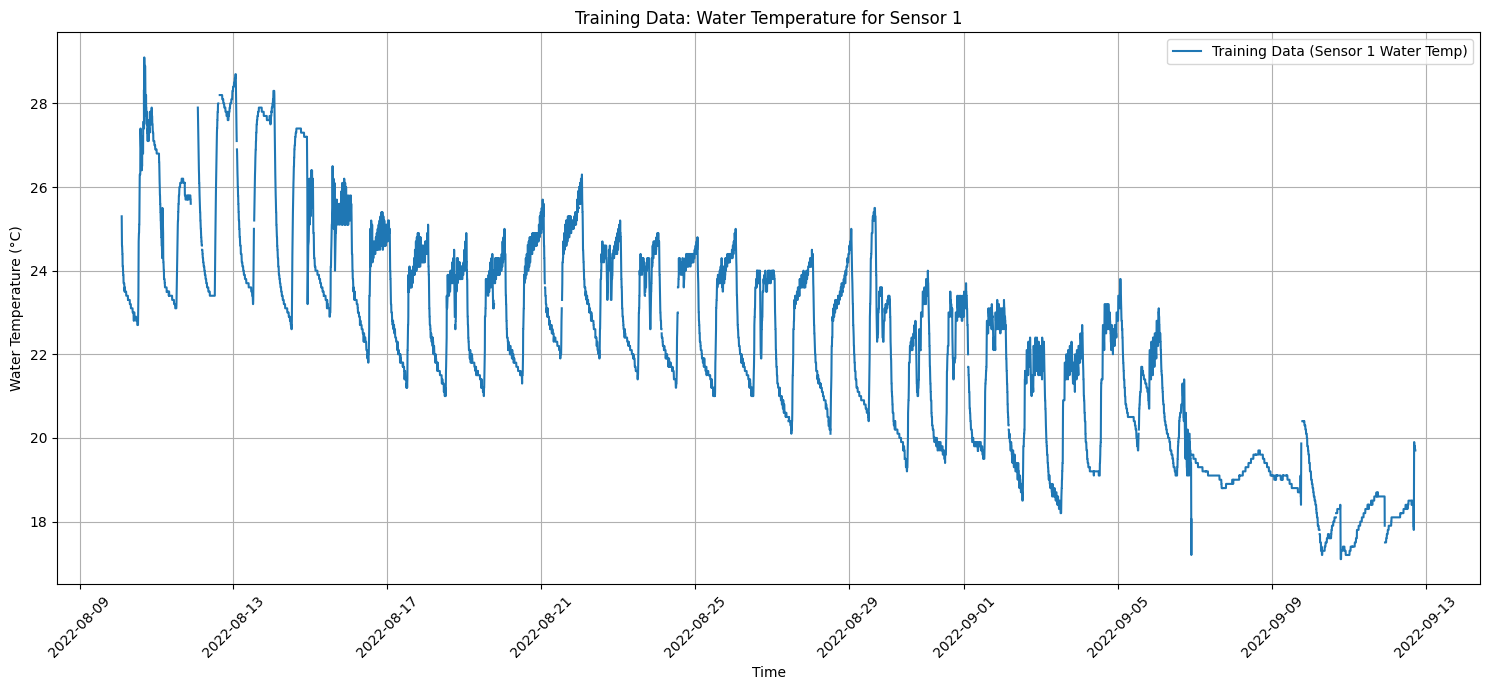

In [25]:
plt.figure(figsize=(15, 7))
plt.plot(train_data.index, train_data, label='Training Data (Sensor 1 Water Temp)')
plt.title('Training Data: Water Temperature for Sensor 1')
plt.xlabel('Time')
plt.ylabel('Water Temperature (°C)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(timeseries):
    # Perform Augmented Dickey-Fuller test
    print('Results of Augmented Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    print(dfoutput)

    # Check p-value for stationarity
    if dfoutput['p-value'] <= 0.05:
        print("\nConclusion: The time series is likely stationary (p-value <= 0.05).")
    else:
        print("\nConclusion: The time series is likely NOT stationary (p-value > 0.05). Differencing may be required.")

# Fill any NaN values in train_data before checking stationarity
train_data_filled = train_data.interpolate(method='linear')

check_stationarity(train_data_filled)

Results of Augmented Dickey-Fuller Test:
Test Statistic                   -4.584080
p-value                           0.000138
#Lags Used                       38.000000
Number of Observations Used    9648.000000
Critical Value (1%)              -3.431028
Critical Value (5%)              -2.861840
Critical Value (10%)             -2.566929
dtype: float64

Conclusion: The time series is likely stationary (p-value <= 0.05).


Based on the plot and the Augmented Dickey-Fuller (ADF) test results, we can determine the "d" parameter for the ARIMA model. If the p-value is greater than 0.05 and there's a visible trend, differencing (d=1) might be needed. If the p-value is small, the series is likely stationary, and "d" can be 0. We will examine the outputs of the above cells to decide the value for `d`.

In [28]:
# Install pmdarima for auto_arima functionality
!pip install pmdarima
print("pmdarima installed.")

pmdarima installed.


In [29]:
import pmdarima as pm

# Find optimal ARIMA parameters (p, d, q) using auto_arima
# We set d=0 as we've already determined the series is stationary.
# seasonal=False is used because we are not considering seasonality for now.
# stepwise=True for efficiency.
model_auto_arima = pm.auto_arima(train_data_filled,
                                 start_p=0, max_p=5, # Search for p from 0 to 5
                                 start_q=0, max_q=5, # Search for q from 0 to 5
                                 d=0,                 # We already determined d=0
                                 seasonal=False,
                                 stepwise=True,
                                 suppress_warnings=True,
                                 trace=True)

print("Optimal ARIMA orders (p, d, q) for Sensor 1 water_temp:", model_auto_arima.order)

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=87735.158, Time=0.10 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.90 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=1.73 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-9712.353, Time=1.24 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-9741.455, Time=7.43 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=2.71 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=-9729.786, Time=6.49 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-9842.902, Time=2.94 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-9724.161, Time=0.98 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=-9888.181, Time=5.17 sec
 ARIMA(4,0,2)(0,0,0)[0]             : AIC=-9822.279, Time=4.19 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=-10406.158, Time=7.42 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=-9827.005, Time=4.59 sec
 ARIMA(4,0,3)(0,0,0)[0]             : AIC=-10167.384, Time=7.93 sec
 ARIMA(3,0,4)(0,0,0)[0]            

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA Model for Sensor 1 water_temp fitted successfully.
                               SARIMAX Results                                
Dep. Variable:             water_temp   No. Observations:                 9687
Model:                 ARIMA(3, 0, 5)   Log Likelihood                5463.198
Date:                Wed, 18 Feb 2026   AIC                         -10906.397
Time:                        06:55:15   BIC                         -10834.611
Sample:                    08-10-2022   HQIC                        -10882.059
                         - 09-12-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         22.2650     13.423      1.659      0.097      -4.043      48.573
ar.L1          0.5470      0.005    100.365      0.000       0.536       0

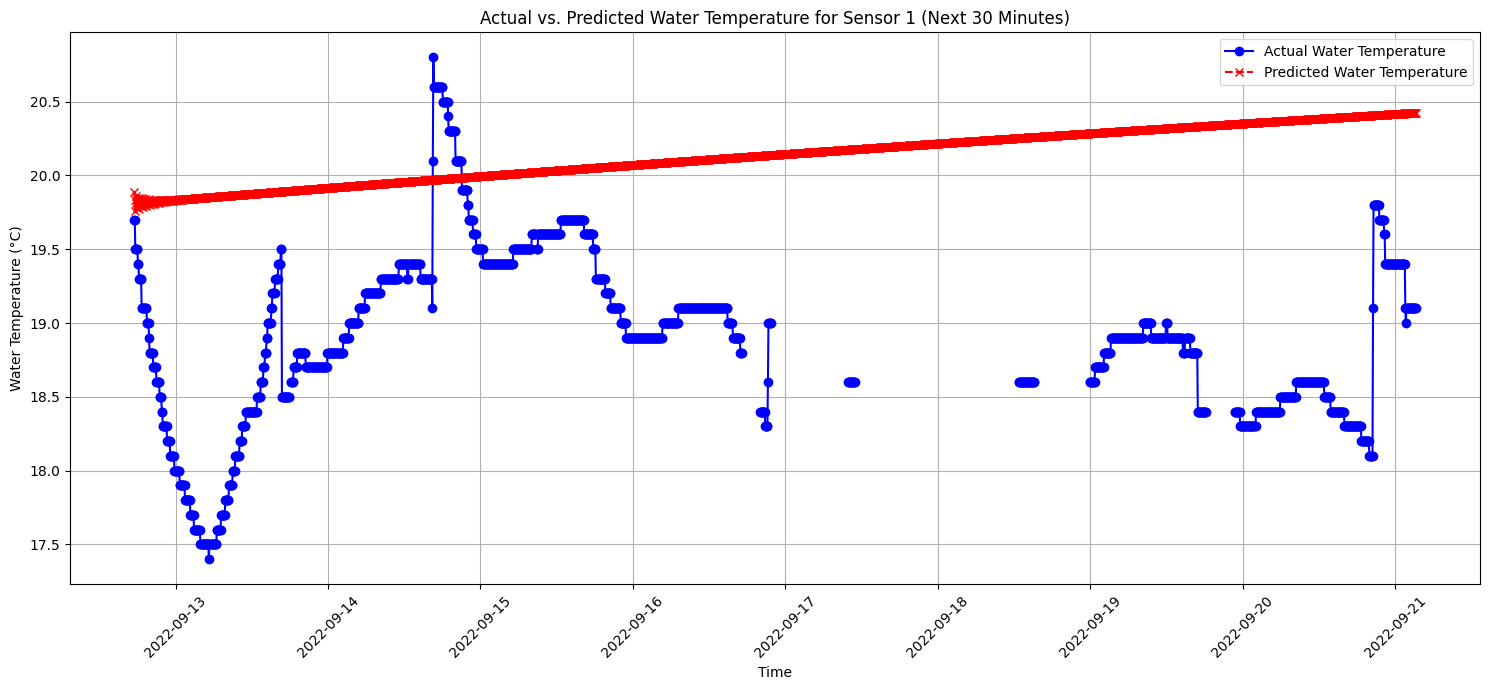

In [30]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model with the identified optimal orders
# model_auto_arima.order contains (p, d, q)
# train_data_filled is used to ensure no NaN values
model = ARIMA(train_data_filled, order=model_auto_arima.order)
model_fit = model.fit()

print("ARIMA Model for Sensor 1 water_temp fitted successfully.")
print(model_fit.summary())

# Generate predictions for the next 30 minutes (6 steps, as each step is 5 minutes)
# The 'start' argument is the index of the first prediction, which is the length of the training data.
# The 'end' argument is the index of the last prediction.
predictions = model_fit.predict(start=len(train_data_filled), end=len(train_data_filled) + len(test_data) - 1)

print("\nPredicted values for the next 30 minutes (Sensor 1 water_temp):\n", predictions)
print("Length of predictions:", len(predictions))

plt.figure(figsize=(15, 7))
plt.plot(test_data.index, test_data, label='Actual Water Temperature', color='blue', marker='o')
plt.plot(predictions.index, predictions, label='Predicted Water Temperature', color='red', linestyle='--', marker='x')
plt.title('Actual vs. Predicted Water Temperature for Sensor 1 (Next 30 Minutes)')
plt.xlabel('Time')
plt.ylabel('Water Temperature (°C)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

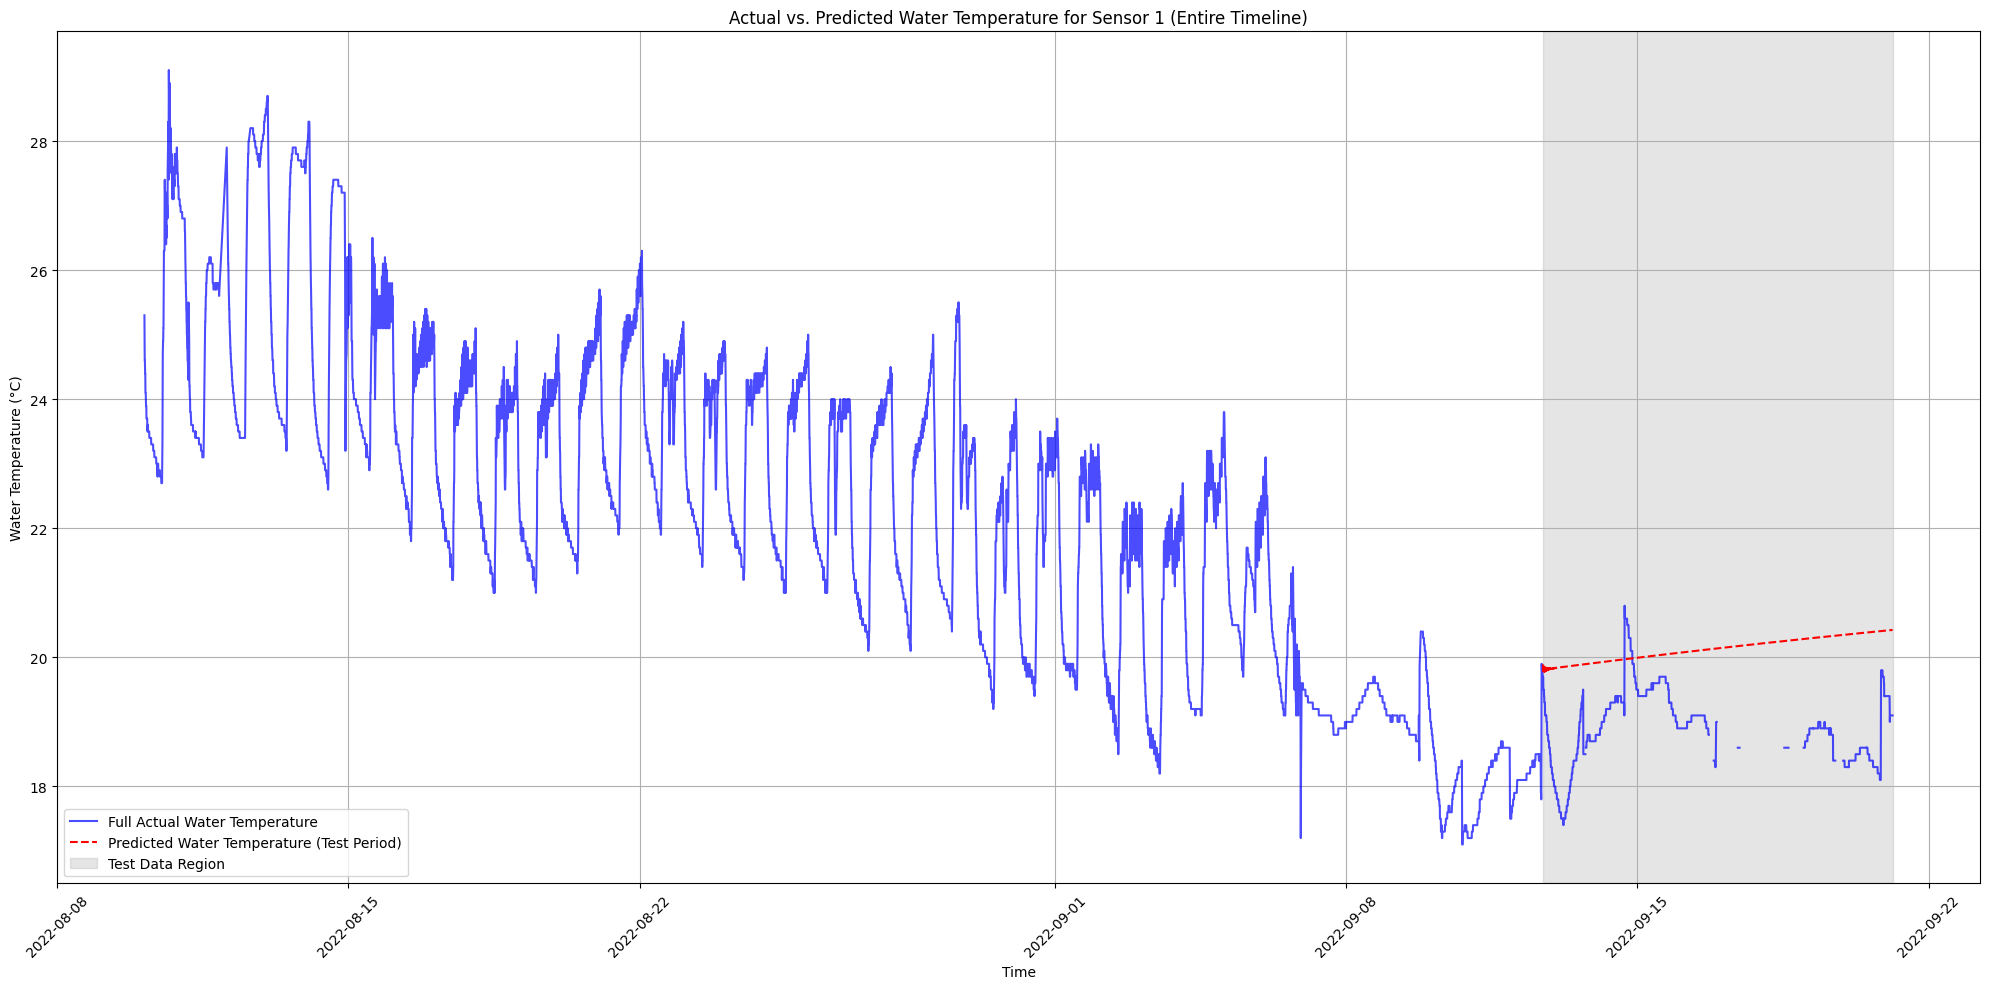

In [33]:
# Combine training and testing data for the full actual timeline
full_actual_data = pd.concat([train_data_filled, test_data])

plt.figure(figsize=(20, 10))

# Plot the entire actual data
plt.plot(full_actual_data.index, full_actual_data, label='Full Actual Water Temperature', color='blue', alpha=0.7)

# Plot the predicted values, aligning them with the test data timeline
plt.plot(predictions.index, predictions, label='Predicted Water Temperature (Test Period)', color='red', linestyle='--')

# Highlight the test data region for clarity
plt.axvspan(test_data.index.min(), test_data.index.max(), color='grey', alpha=0.2, label='Test Data Region')

plt.title('Actual vs. Predicted Water Temperature for Sensor 1 (Entire Timeline)')
plt.xlabel('Time')
plt.ylabel('Water Temperature (°C)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Perform a time series analysis using the ARIMA on Sensor 2 now.

In [34]:
water_temp_sensor2 = df_sensor2['water_temp']

# Calculate the split point (80% for training, 20% for testing)
split_point_sensor2 = int(len(water_temp_sensor2) * 0.8)

# Split data into training and testing sets
train_data_sensor2 = water_temp_sensor2.iloc[:split_point_sensor2]
test_data_sensor2 = water_temp_sensor2.iloc[split_point_sensor2:]

print("Shape of training data for Sensor 2:", train_data_sensor2.shape)
print("Shape of testing data for Sensor 2:", test_data_sensor2.shape)
print("\nFirst 5 values of training data for Sensor 2:\n", train_data_sensor2.head())
print("\nLast 5 values of testing data for Sensor 2:\n", test_data_sensor2.tail())

Shape of training data for Sensor 2: (9686,)
Shape of testing data for Sensor 2: (2422,)

First 5 values of training data for Sensor 2:
 time
2022-08-10 02:20:00+00:00    23.9
2022-08-10 02:25:00+00:00    23.9
2022-08-10 02:30:00+00:00    23.9
2022-08-10 02:35:00+00:00    23.9
2022-08-10 02:40:00+00:00    23.9
Freq: 5min, Name: water_temp, dtype: float64

Last 5 values of testing data for Sensor 2:
 time
2022-09-21 02:55:00+00:00    19.0
2022-09-21 03:00:00+00:00    19.0
2022-09-21 03:05:00+00:00    19.0
2022-09-21 03:10:00+00:00    19.0
2022-09-21 03:15:00+00:00    19.0
Freq: 5min, Name: water_temp, dtype: float64


## Plot Training Data for Sensor 2



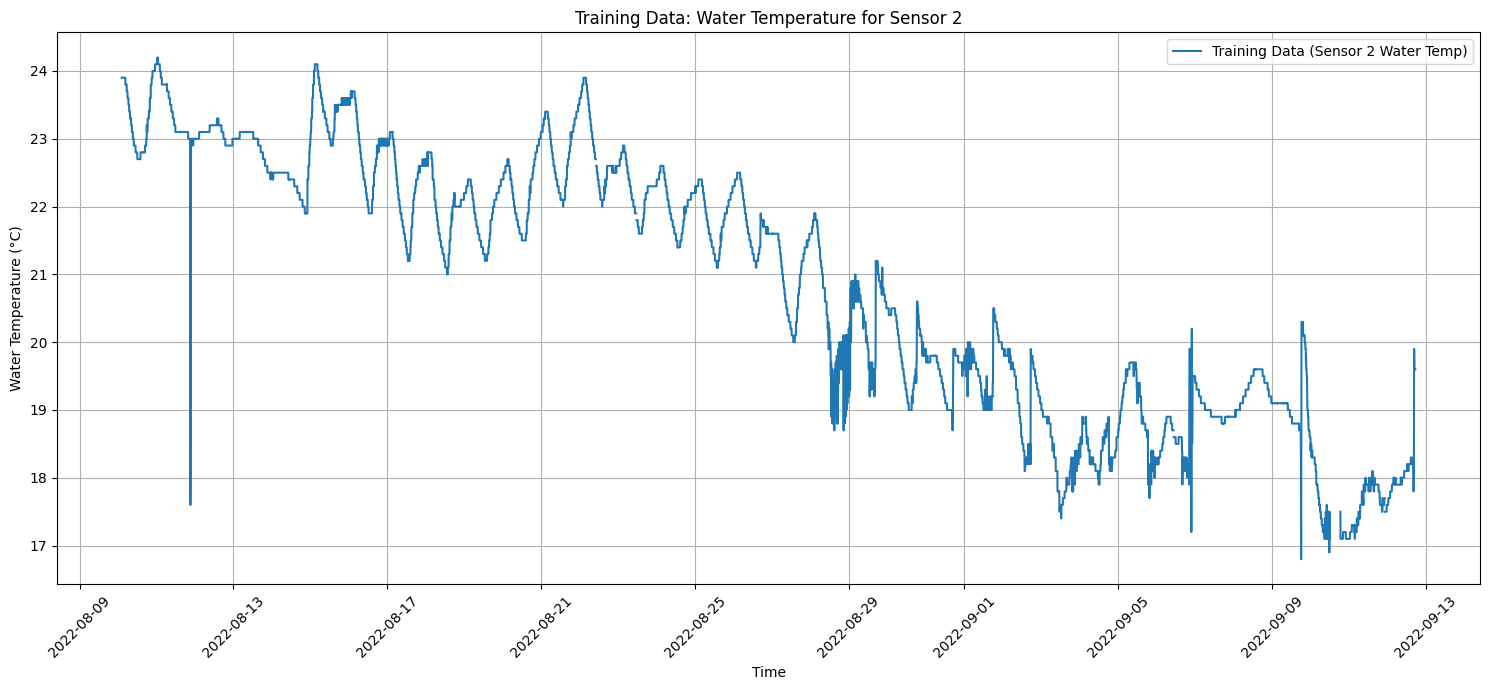

In [35]:
plt.figure(figsize=(15, 7))
plt.plot(train_data_sensor2.index, train_data_sensor2, label='Training Data (Sensor 2 Water Temp)')
plt.title('Training Data: Water Temperature for Sensor 2')
plt.xlabel('Time')
plt.ylabel('Water Temperature (°C)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Check the stationarity of the time series data for Sensor 2's water temperature. This step will help in determining the appropriate 'd' parameter for the ARIMA model.


In [36]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(timeseries):
    # Perform Augmented Dickey-Fuller test
    print('Results of Augmented Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    print(dfoutput)

    # Check p-value for stationarity
    if dfoutput['p-value'] <= 0.05:
        print("\nConclusion: The time series is likely stationary (p-value <= 0.05).")
    else:
        print("\nConclusion: The time series is likely NOT stationary (p-value > 0.05). Differencing may be required.")

# Fill any NaN values in train_data_sensor2 before checking stationarity
train_data_sensor2_filled = train_data_sensor2.interpolate(method='linear')

check_stationarity(train_data_sensor2_filled)

Results of Augmented Dickey-Fuller Test:
Test Statistic                   -2.427335
p-value                           0.134170
#Lags Used                       37.000000
Number of Observations Used    9648.000000
Critical Value (1%)              -3.431028
Critical Value (5%)              -2.861840
Critical Value (10%)             -2.566929
dtype: float64

Conclusion: The time series is likely NOT stationary (p-value > 0.05). Differencing may be required.


Since the Augmented Dickey-Fuller test indicated that the time series for Sensor 2's water temperature is not stationary (p-value > 0.05), differencing is required. I will use pmdarima.auto_arima to automatically determine the optimal (p, d, q) parameters, allowing it to search for the appropriate differencing order d.



In [37]:
import pmdarima as pm

# Find optimal ARIMA parameters (p, d, q) using auto_arima for Sensor 2
# We set d to be automatically determined, given the non-stationarity result.
# seasonal=False is used because we are not considering seasonality for now.
# stepwise=True for efficiency.
model_auto_arima_sensor2 = pm.auto_arima(train_data_sensor2_filled,
                                          start_p=0, max_p=5, # Search for p from 0 to 5
                                          start_q=0, max_q=5, # Search for q from 0 to 5
                                          d=None,              # Let auto_arima determine optimal d
                                          seasonal=False,
                                          stepwise=True,
                                          suppress_warnings=True,
                                          trace=True)

print("Optimal ARIMA orders (p, d, q) for Sensor 2 water_temp:", model_auto_arima_sensor2.order)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-17899.901, Time=1.21 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-18277.868, Time=0.59 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-18450.679, Time=3.90 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-17901.694, Time=0.09 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-18554.226, Time=4.91 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-19009.777, Time=4.11 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-18693.537, Time=2.19 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-19007.863, Time=8.79 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-18526.511, Time=8.78 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-18950.497, Time=6.75 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=-18758.280, Time=2.53 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=-19111.862, Time=10.79 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=16.57 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=-18588.852, Time=12.56 sec
 ARIMA(2,

Now that the optimal ARIMA orders have been determined for Sensor 2's water temperature, the next step is to fit the ARIMA model to the training data and then generate predictions for the test set. This will allow for evaluation of the model's performance.



ARIMA Model for Sensor 2 water_temp fitted successfully.
                               SARIMAX Results                                
Dep. Variable:             water_temp   No. Observations:                 9686
Model:                 ARIMA(5, 1, 0)   Log Likelihood                9647.707
Date:                Wed, 18 Feb 2026   AIC                         -19283.413
Time:                        08:03:16   BIC                         -19240.343
Sample:                    08-10-2022   HQIC                        -19268.811
                         - 09-12-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1797      0.001    144.836      0.000       0.177       0.182
ar.L2         -0.2233      0.003    -84.353      0.000      -0.228      -0

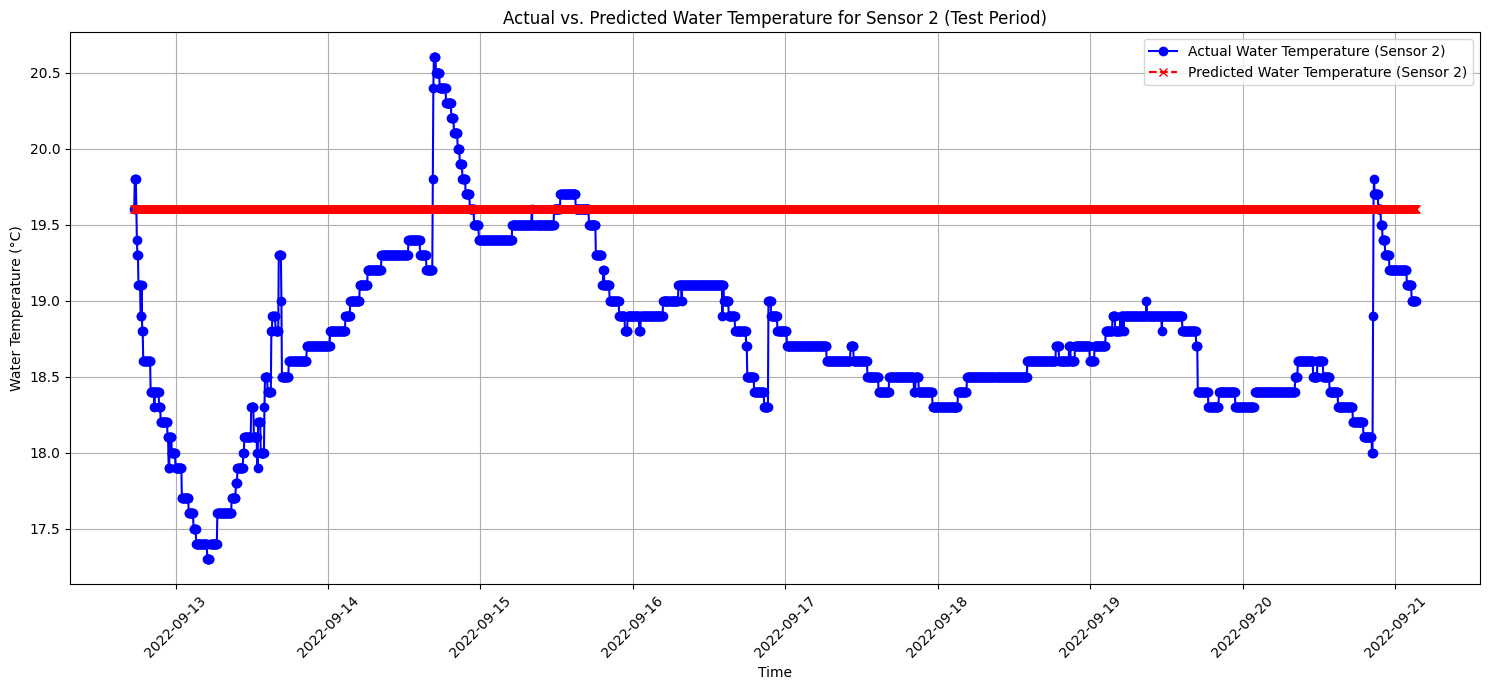

In [38]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model with the identified optimal orders for Sensor 2
# model_auto_arima_sensor2.order contains (p, d, q)
# train_data_sensor2_filled is used to ensure no NaN values
model_sensor2 = ARIMA(train_data_sensor2_filled, order=model_auto_arima_sensor2.order)
model_fit_sensor2 = model_sensor2.fit()

print("ARIMA Model for Sensor 2 water_temp fitted successfully.")
print(model_fit_sensor2.summary())

# Generate predictions for the test data length
# The 'start' argument is the index of the first prediction, which is the length of the training data.
# The 'end' argument is the index of the last prediction.
predictions_sensor2 = model_fit_sensor2.predict(start=len(train_data_sensor2_filled), end=len(train_data_sensor2_filled) + len(test_data_sensor2) - 1)

print("\nPredicted values for Sensor 2 water_temp:\n", predictions_sensor2)
print("Length of predictions_sensor2:", len(predictions_sensor2))

plt.figure(figsize=(15, 7))
plt.plot(test_data_sensor2.index, test_data_sensor2, label='Actual Water Temperature (Sensor 2)', color='blue', marker='o')
plt.plot(predictions_sensor2.index, predictions_sensor2, label='Predicted Water Temperature (Sensor 2)', color='red', linestyle='--', marker='x')
plt.title('Actual vs. Predicted Water Temperature for Sensor 2 (Test Period)')
plt.xlabel('Time')
plt.ylabel('Water Temperature (°C)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

To provide a complete visualization of the model's performance, I will plot the entire actual water temperature data for Sensor 2 (combining training and test data) along with the predicted values from the ARIMA model, highlighting the test data region.



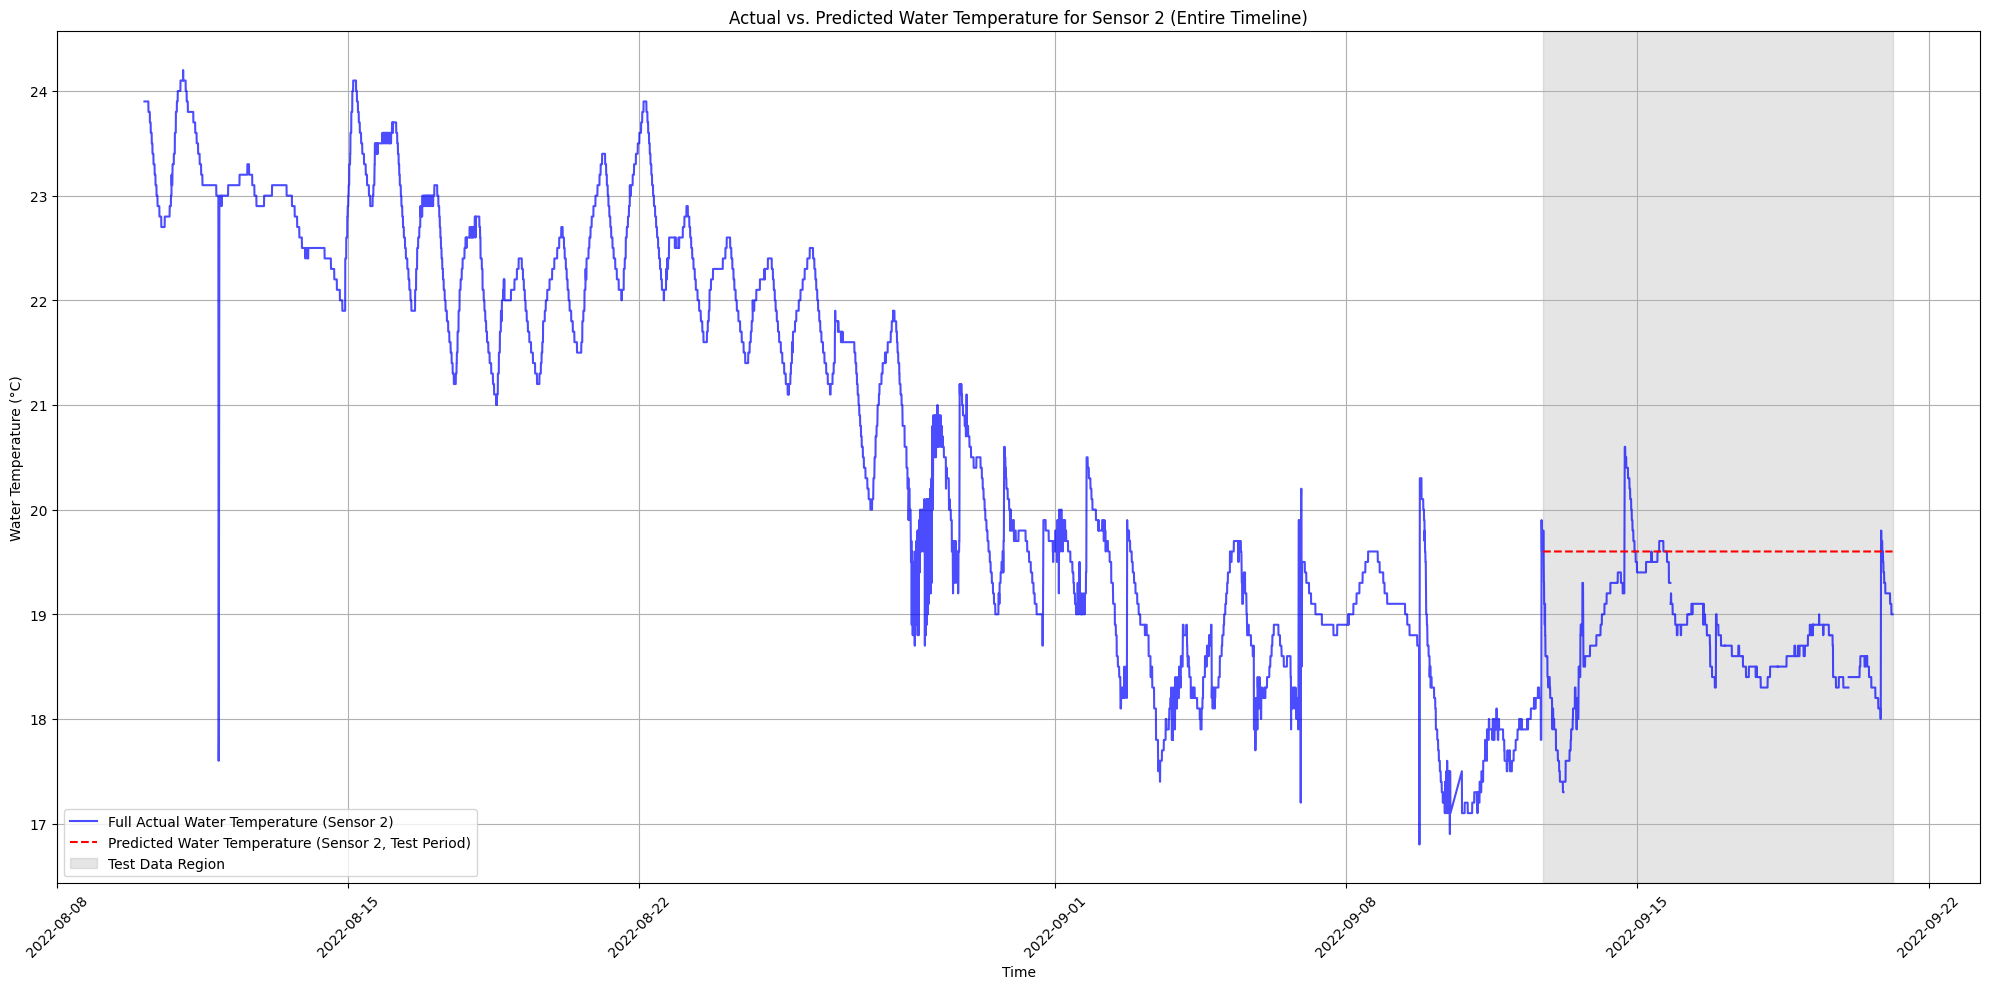

In [39]:
full_actual_data_sensor2 = pd.concat([train_data_sensor2_filled, test_data_sensor2])

plt.figure(figsize=(20, 10))

# Plot the entire actual data
plt.plot(full_actual_data_sensor2.index, full_actual_data_sensor2, label='Full Actual Water Temperature (Sensor 2)', color='blue', alpha=0.7)

# Plot the predicted values, aligning them with the test data timeline
plt.plot(predictions_sensor2.index, predictions_sensor2, label='Predicted Water Temperature (Sensor 2, Test Period)', color='red', linestyle='--')

# Highlight the test data region for clarity
plt.axvspan(test_data_sensor2.index.min(), test_data_sensor2.index.max(), color='grey', alpha=0.2, label='Test Data Region')

plt.title('Actual vs. Predicted Water Temperature for Sensor 2 (Entire Timeline)')
plt.xlabel('Time')
plt.ylabel('Water Temperature (°C)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Plot water temp for both sensors

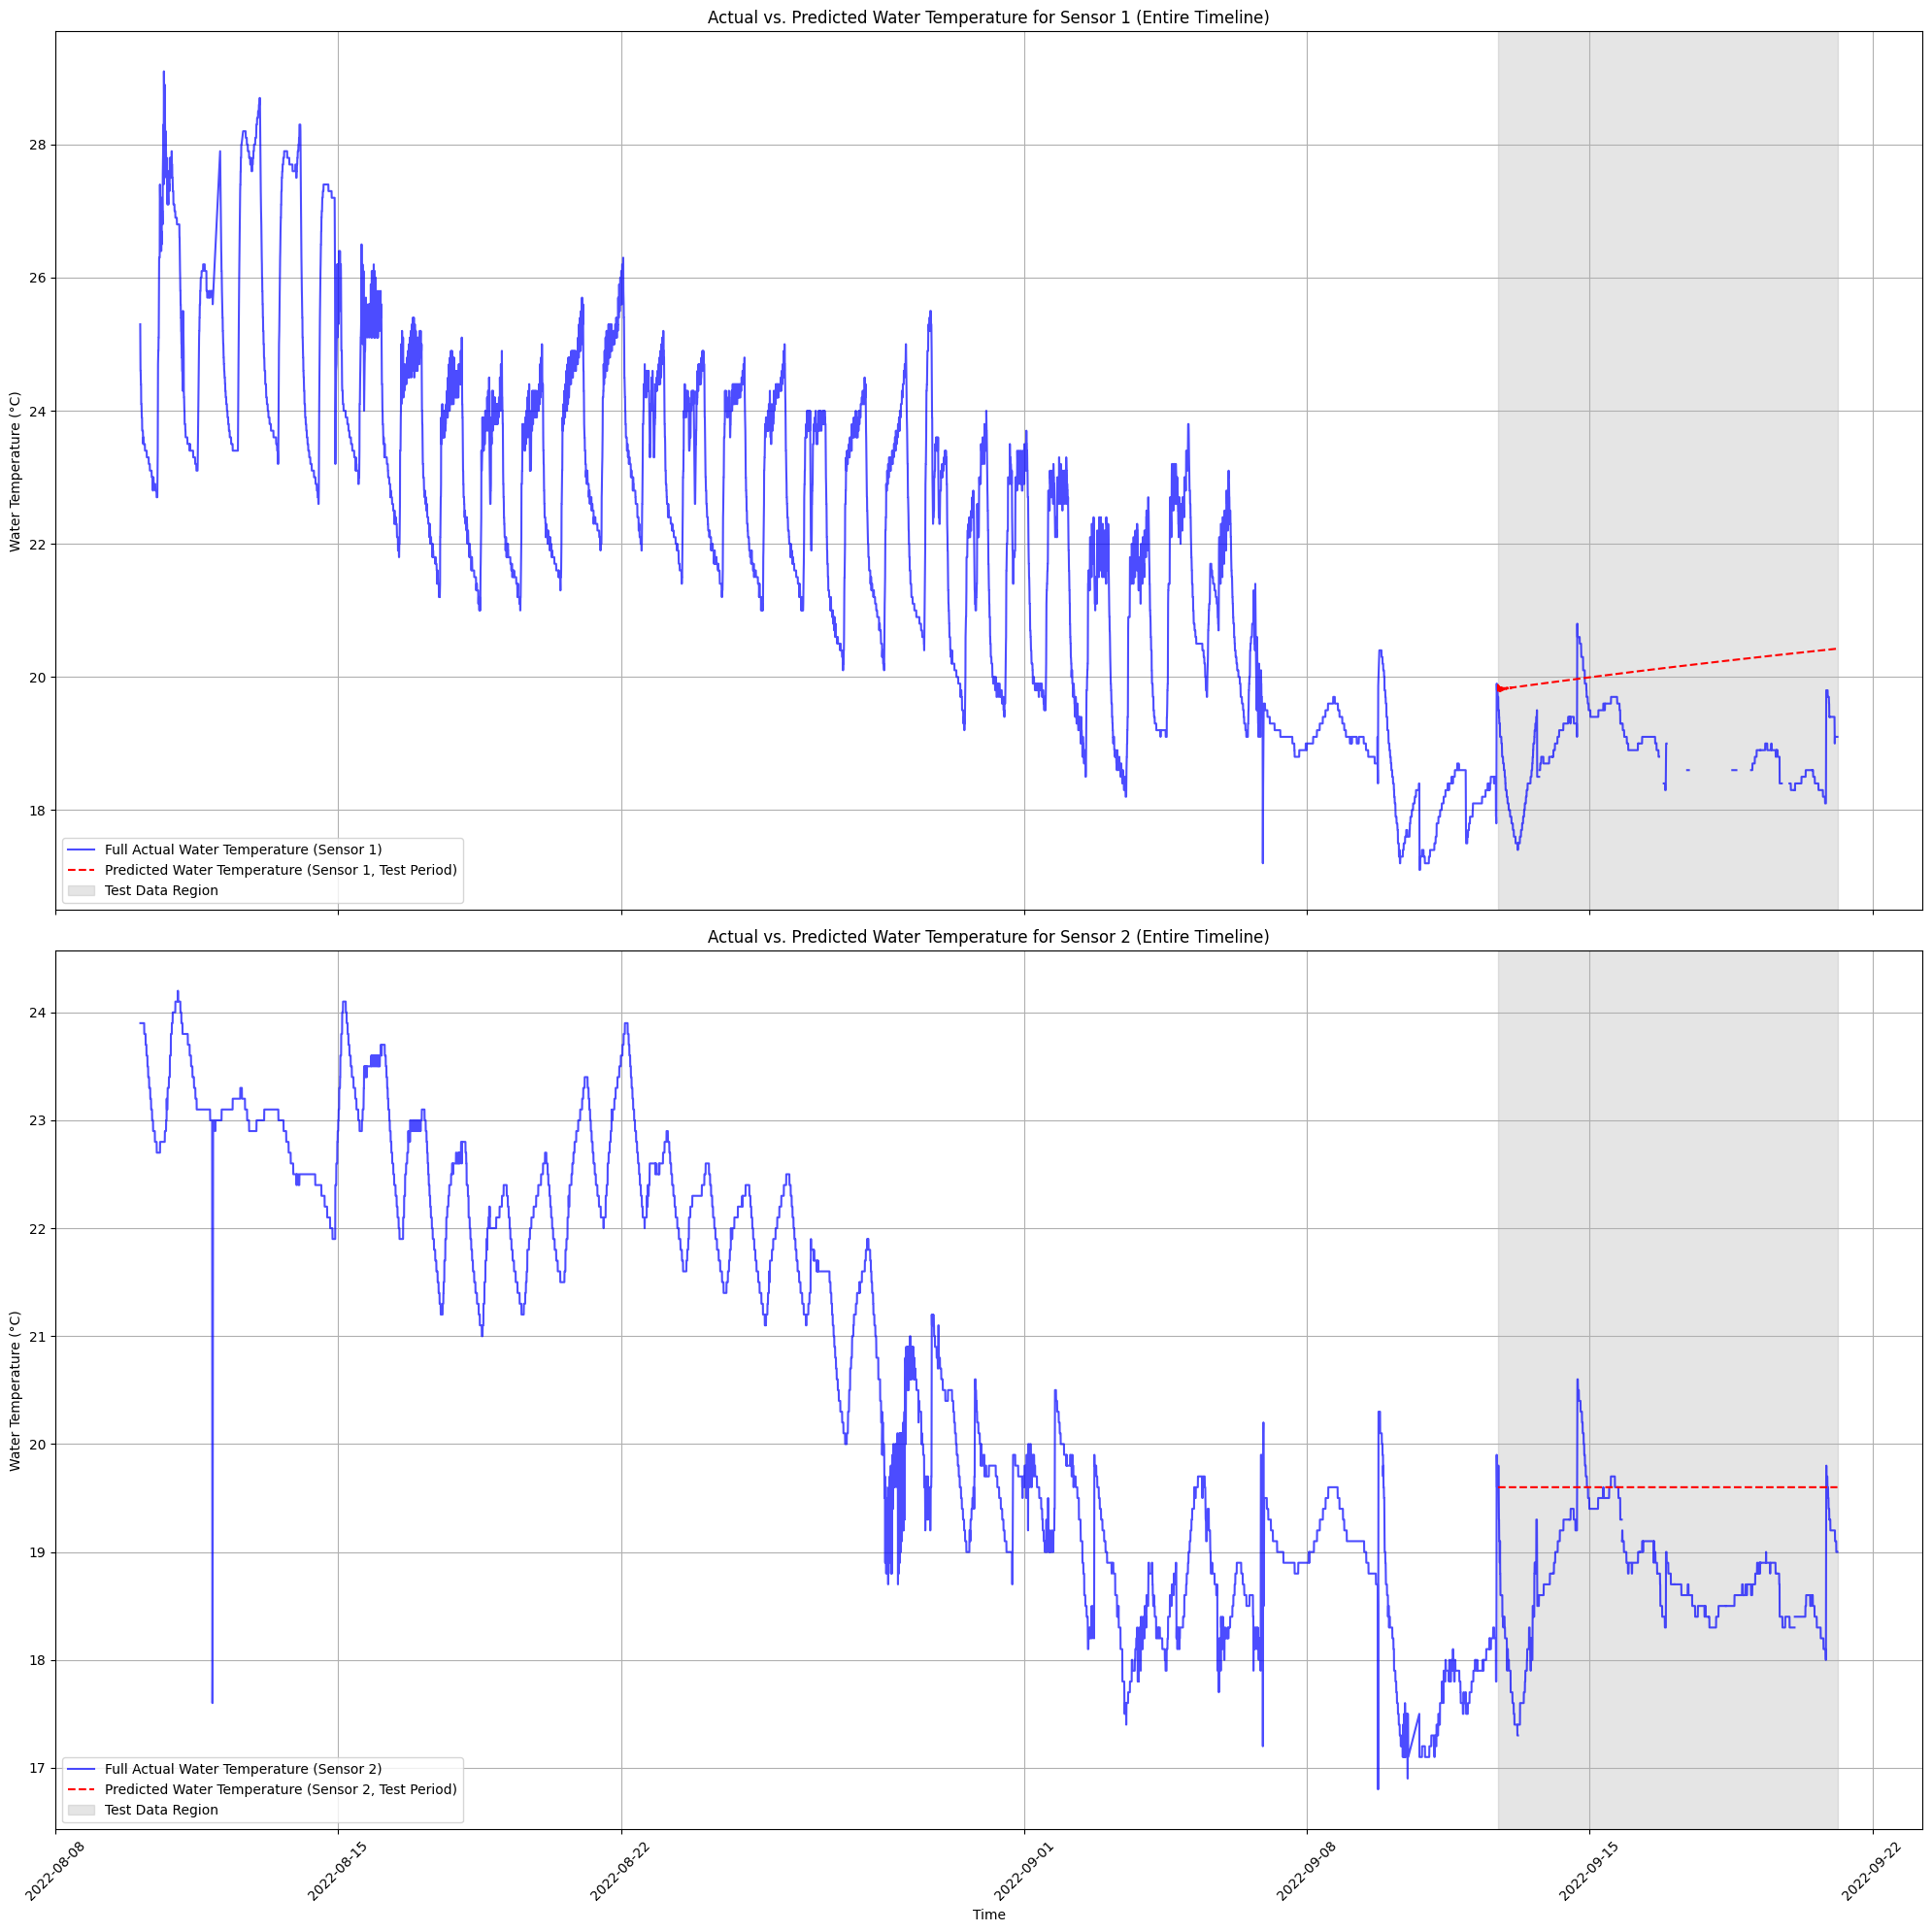

In [40]:
fig, axes = plt.subplots(2, 1, figsize=(20, 20), sharex=True)

# Plot for Sensor 1
full_actual_data = pd.concat([train_data_filled, test_data])
axes[0].plot(full_actual_data.index, full_actual_data, label='Full Actual Water Temperature (Sensor 1)', color='blue', alpha=0.7)
axes[0].plot(predictions.index, predictions, label='Predicted Water Temperature (Sensor 1, Test Period)', color='red', linestyle='--')
axes[0].axvspan(test_data.index.min(), test_data.index.max(), color='grey', alpha=0.2, label='Test Data Region')
axes[0].set_title('Actual vs. Predicted Water Temperature for Sensor 1 (Entire Timeline)')
axes[0].set_ylabel('Water Temperature (°C)')
axes[0].legend()
axes[0].grid(True)

# Plot for Sensor 2
full_actual_data_sensor2 = pd.concat([train_data_sensor2_filled, test_data_sensor2])
axes[1].plot(full_actual_data_sensor2.index, full_actual_data_sensor2, label='Full Actual Water Temperature (Sensor 2)', color='blue', alpha=0.7)
axes[1].plot(predictions_sensor2.index, predictions_sensor2, label='Predicted Water Temperature (Sensor 2, Test Period)', color='red', linestyle='--')
axes[1].axvspan(test_data_sensor2.index.min(), test_data_sensor2.index.max(), color='grey', alpha=0.2, label='Test Data Region')
axes[1].set_title('Actual vs. Predicted Water Temperature for Sensor 2 (Entire Timeline)')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Water Temperature (°C)')
axes[1].legend()
axes[1].grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Summary

For Sensor 1, the water temperature series was found to be stationary (d=0), and the optimal ARIMA parameters were determined as (3, 0, 5). However, the model's predictions for the test period appeared significantly flat, failing to capture the observed volatility and cyclical patterns in the actual data.

Similarly, for Sensor 2, while the series was found to be non-stationary (p-value > 0.05) requiring differencing (d=1), its optimal ARIMA parameters were identified as (5, 1, 0). Despite the differencing, the predictions for Sensor 2 also exhibited a largely flat line, struggling to track the actual temperature fluctuations.

In comparison, both non-seasonal ARIMA models demonstrated limitations in forecasting water temperature. They consistently produced smoothed, unresponsive predictions that did not accurately reflect the dynamic changes and inherent volatility present in the actual data for either sensor.